In [1]:
from tqdm import tqdm
import networkx as nx
from copy import deepcopy as cp
import requests
import numpy as np
import json
import codecs
import pandas as pd
import pickle
import re
import os
import codecs
import random

In [2]:
import json
from tqdm import tqdm
import numpy as np

In [3]:
import sklearn as skl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.cm as cm
import pylab

In [4]:
from copy import deepcopy as cp

In [5]:
from json import JSONDecodeError

In [6]:
def create_tsne_for_plot(data, labels, highlight = None, size = None, nc = 10):
    np.random.seed(0)
    max_label = max(labels)
    # max_items = np.random.choice(range(data.shape[0]), size=len(labels), replace=False)
    
    # pca = PCA(random_state = 1, n_components=2).fit_transform(np.asarray(data))
    tsne = TSNE(random_state = 1, n_iter = 5000).fit_transform(PCA(n_components=nc).fit_transform(np.asarray(data)))
    
    label_colors = [cm.hsv(i/max_label) for i in labels]

    return tsne[:,0], tsne[:,1], label_colors

In [7]:
def collect_preds(model, testloader,criterion, verbal = True, rec_loss = True, scores = False):
    preds = []
    true_tags = []
    was_training = copy.deepcopy(model.model.training)
    model.model.eval()
    
    running_loss = 0.0
    running_corrects = 0
    
    if(verbal):
        iterator = tqdm(testloader)
    else:
        iterator = testloader
        
    for inputs, labels in iterator:
        inputs = inputs[0]
        labels = labels[0]
        
        numlabel = torch.tensor(model.model.config.label2id[labels]).to(device)
        
        with torch.no_grad():
            inp = model.tokenizer(inputs, return_tensors = "pt")
            inp = inp.to(device)
            outputs = model.model(**inp)
        res = outputs.logits[0][0]
        if scores:
            pred = (outputs.logits[0])
            preds.append(pred.detach().to('cpu').numpy())
        else:
            pred = int(torch.argmax(res))
            preds.append(pred)
            running_corrects += int(pred == numlabel)
        true_tags.append(int(numlabel.cpu().detach().numpy()))
        loss = criterion(res, numlabel)
        
            
        running_loss += loss.item()
        
    ovl_loss = running_loss / len(testloader)
    ovl_acc = float(running_corrects) / len(testloader)

    if(verbal):
        print('test | loss function val: {} accuracy: {}'.format(ovl_loss, ovl_acc))
    
    if(was_training):
       model.model.train()

    return preds, true_tags
    # if(rec_loss):
    #     return ovl_acc, ovl_loss
    # return ovl_acc

def test(model, testloader,criterion, verbal = True, rec_loss = True):
    was_training = copy.deepcopy(model.model.training)
    model.model.eval()
    
    running_loss = 0.0
    running_corrects = 0
    
    if(verbal):
        iterator = tqdm(testloader)
    else:
        iterator = testloader
        
    for inputs, labels in iterator:
        inputs = inputs[0]
        labels = labels[0]
        
        numlabel = torch.tensor(model.model.config.label2id[labels]).to(device)
        
        with torch.no_grad():
            inp = model.tokenizer(inputs, return_tensors = "pt")
            inp = inp.to(device)
            outputs = model.model(**inp)
        res = outputs.logits[0][0]
        pred = int(torch.argmax(res))
        loss = criterion(res, numlabel)
        
        running_loss += loss.item()
        running_corrects += int(pred == numlabel)
        
    ovl_loss = running_loss / len(testloader)
    ovl_acc = float(running_corrects) / len(testloader)

    if(verbal):
        print('test | loss function val: {} accuracy: {}'.format(ovl_loss, ovl_acc))
    
    if(was_training):
       model.model.train()
        
    if(rec_loss):
        return ovl_acc, ovl_loss
    return ovl_acc

import time
import copy
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=25,
                verbal = True, bert_dropout = True):
    
    model.model.classifier.train()
    
    if(bert_dropout):
        model.model.roberta.train()
    else:
        model.model.roberta.eval()
    #--
    
    tracing = []
    since = time.time()

    best_model_wts = copy.deepcopy(model.model.state_dict())
    best_acc = 0.0
    
    if(verbal):
        iterator_1 = range(num_epochs)
    else:
        iterator_1 = tqdm(range(num_epochs))
            
    #--
    model.model.roberta.eval()
    model.model.classifier.eval()
    
    train_accurcy, train_loss = test(model,trainloader,criterion, verbal = verbal, rec_loss = True)
    validation_accurcy, validation_loss = test(model,valloader,criterion, verbal = verbal)
    
    if(bert_dropout):
        model.model.roberta.train()
        model.model.classifier.train()
    else:
        model.model.roberta.eval()
        model.model.classifier.train()
    #--
        
    tracing.append([-1,train_loss, validation_loss, train_accurcy,validation_accurcy])
    
    for epoch in iterator_1:
        torch.cuda.empty_cache()

        running_loss = 0.0
        running_corrects = 0
        
        if(verbal):
            iterator = tqdm(trainloader)
        else:
            iterator = trainloader
            
        for inputs, labels in iterator:
            inputs = inputs[0]
            labels = labels[0]
            
            #--------
            optimizer.zero_grad()
            #--------

            numlabel = torch.tensor(model.model.config.label2id[labels]).to(device)

            inp = model.tokenizer(inputs, return_tensors = "pt")
            inp = inp.to(device)
            outputs = model.model(**inp)
            
            res = outputs.logits[0][0]
            pred = int(torch.argmax(res))

            loss = criterion(res, numlabel)
            
            #обучение
            loss.backward()
            optimizer.step()
            #--------
            
            #трейсинг
            running_loss += loss.item()
            running_corrects += int(pred == numlabel)

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = float(running_corrects) / len(trainloader)

        if(verbal):
            print('epoch {} | loss function val: {} accuracy: {}'.format(epoch, epoch_loss, epoch_acc))

        #--
        model.model.roberta.eval()
        model.model.classifier.eval()
        
        validation_accurcy, validation_loss = test(model,valloader,criterion, verbal = verbal)
        
        if(bert_dropout):
            model.model.roberta.train()
            model.model.classifier.train()
        else:
            model.model.roberta.eval()
            model.model.classifier.train()
        #--
        
        tracing.append([epoch,epoch_loss, validation_loss, epoch_acc,validation_accurcy])
        
        if validation_accurcy >= best_acc:
            del best_model_wts
            torch.cuda.empty_cache()
            best_acc = validation_accurcy
            best_model_wts = copy.deepcopy(model.model.state_dict())

        if(verbal):
            print()

    time_elapsed = time.time() - since
    
    #if(verbal):
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.model.load_state_dict(best_model_wts)
    
    #--
    model.model.classifier.eval()
    model.model.roberta.eval()
    
    return model, np.array(tracing), best_acc

# Обучение нейронки для структурной сегментации

In [78]:
dset_dir_name = "structure_dataset"
dset_sentences_ = []
dset_tags_ = []
dset_res_2 = {}
for elm in os.listdir(dset_dir_name):
    if elm.find('.txt') != -1 and  re.match("[\d]", elm):
        with codecs.open( dset_dir_name + "/" + elm, 'r', encoding = "utf-8") as f:
            cur_tag = None
            for line in f:
                if line.strip("\n\r\"- ") == "":
                    continue
                s_line = line.replace("*","")
                if s_line.find('Цель работы') != -1:
                    cur_tag = "Goal"
                    continue
                if s_line.find('Результаты, полученные в работе') != -1:
                    cur_tag = "Resl"
                    continue
                if s_line.find('Область применения') != -1:
                    cur_tag = "Obl"
                    continue
                if s_line.find('алгоритмы и методы') != -1:
                    cur_tag = "Algo"
                    continue
                if s_line.find('Прочий текст') != -1:
                    cur_tag = "None"
                    continue
                # если это не заголовочная строка, то добавляем в датасет.
                dset_sentences_.append(line.strip("\n\r\"- "))
                dset_tags_.append(cur_tag)
                
                dset_res_2.setdefault(cur_tag, [])
                dset_res_2[cur_tag].append(line.strip("\n\r\"- "))

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\User\AppData\Local\Temp\ipykernel_9472\3159435452.py:6: SyntaxWarning: invalid escape sequence '\d'
  if elm.find('.txt') != -1 and  re.match("[\d]", elm):


In [75]:
import torch
import sklearn as skl

In [79]:
dset_res_2.keys()

dict_keys(['Goal', 'Resl'])

In [81]:
import pandas as pd

def read_excel_columns(file_path, sheet_name=0):
    """
    Читает Excel-файл и возвращает словарь, где ключи - названия колонок,
    а значения - списки с содержимым этих колонок.
    
    :param file_path: Путь к Excel-файлу
    :param sheet_name: Название или индекс листа (по умолчанию первый лист)
    :return: Словарь с данными колонок
    """
    try:
        # Чтение Excel-файла
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        
        # Создание словаря с данными колонок
        columns_data = {}
        for column in df.columns[2:]:
            col_data = df[column].dropna().tolist()
            columns_data[col_data[0]] = col_data[1:]
            
        return columns_data
    
    except Exception as e:
        print(f"Произошла ошибка: {e}")
        return None

In [82]:
data = read_excel_columns("struct_data.xlsx")

In [83]:
tag_merger = {
    'Сфера примененеия' : "актуальность", # актуальность, область
    'Использованные методыи алгоритмы' : "методы", # заключение / результат
    'Основная идея' : None, # цель / задачи
    'Нет метки' : "нет метки", # методы
    'Перспективы для дальнейших исследований' : None, # нет метки
    'Вывод, заключение' : "результат",
    'Цель' : "задачи",
    'Описание результата' : "результат",
    'Объект исследования' : None,
    'Обсуждение результатов' : "результат",
    'Задачи' : "задачи",
    'Обзор литературы' : None,
    'Актуальность работы' : "актуальность"
}

dset_sentences = []
dset_tags = []
for key in data.keys():
    for elm in data[key]:
        if tag_merger[key] is not None:
            dset_sentences.append(elm)
            dset_tags.append(tag_merger[key])

LabtoNum = {key : i for i, key in enumerate(set(dset_tags))}
NumToLab = {i : key for i, key in enumerate(set(dset_tags))}

# LabtoNum = {"актуальность" : 0, "результат" : 1, "задачи" : 2, "методы" : 3, "нет метки" : 4}
# NumToLab = {0 : "актуальность", 1 : "результат", 2 : "задачи", 3 : "методы", 4 : "нет метки"}

[0.3450971  0.39439668 0.577837   0.59159503 0.20366386]


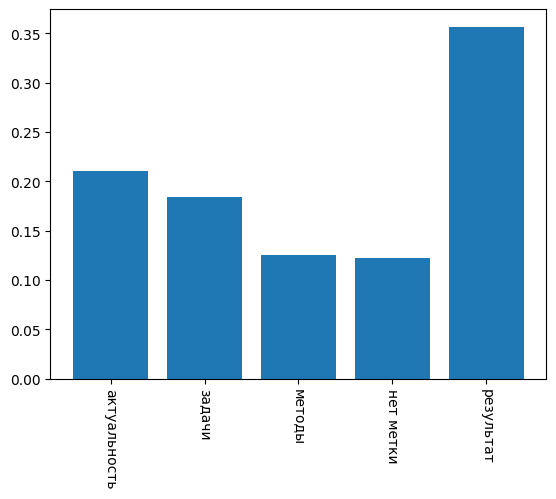

In [84]:
tags_values, tags_freques = np.unique(dset_tags, return_counts = True)
tags_relative_freques = tags_freques / len(dset_tags)
trf_inv = 1 / tags_relative_freques
tags_weights = trf_inv / np.linalg.norm(trf_inv)
print(tags_weights)
pylab.bar(tags_values, tags_relative_freques)
pylab.xticks(rotation=-90)
pylab.show()

In [85]:
class MyDataset:
    def __init__(self,datavals,datatags, shuffle = False, shiffle_seed = 0):            
        self.datavals = datavals
        self.datatags = datatags
        
        if(shuffle):
            self.datavals, self.datatags = skl.utils.shuffle(self.datavals, self.datatags, random_state = shiffle_seed)
            
    def __len__(self):
        return len(self.datavals)
    
    def __getitem__(self,idx):
        return self.datavals[idx], self.datatags[idx]

In [86]:
part = 0.8
data = MyDataset(dset_sentences,dset_tags,shuffle = True, shiffle_seed = 12)
traindata,valdata = skl.model_selection.train_test_split(data, test_size = 0.2, random_state = 0)
traindata = MyDataset([elm[0] for elm in traindata],[elm[1] for elm in traindata],shuffle = False)
valdata = MyDataset([elm[0] for elm in valdata],[elm[1] for elm in valdata],shuffle = False)
trainloader = torch.utils.data.DataLoader(traindata, batch_size = 1)
valloader = torch.utils.data.DataLoader(valdata, batch_size = 1)

In [87]:
# составляем веса в соответствии с распределение м обучающем наборе
tags_values, tags_freques = np.unique(traindata.datatags, return_counts = True)
tags_relative_freques = tags_freques / len(dset_tags)
trf_inv = 1 / tags_relative_freques
tags_weights = trf_inv / np.linalg.norm(trf_inv)

In [88]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [89]:
print(len(traindata))

273


In [90]:
print(len(valdata))

69


In [91]:
print(len(NumToLab))

5


In [92]:
# study.best_params

# {'weight_decay': 0.0000703673153394426,
#  'bert_do': True,
#  'head_dims': 149,
#  'head_im_activation': 0}

In [93]:
from transformers import RobertaForSequenceClassification, RobertaTokenizer, pipeline
tokenizer = RobertaTokenizer.from_pretrained("mlsa-iai-msu-lab/sci-rus-tiny3")
model = RobertaForSequenceClassification.from_pretrained("mlsa-iai-msu-lab/sci-rus-tiny3")
# from transformers import AutoTokenizer, BertForSequenceClassification
# tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased-sentence")
# model = BertForSequenceClassification.from_pretrained("DeepPavlov/rubert-base-cased-sentence")
for param in model.roberta.parameters(): # включаем обучение в берте
    param.requires_grad = True  # 
num_frozen_layers = 1
for i in range(num_frozen_layers):
    for param in model.roberta.encoder.layer[i].parameters():
        param.requires_grad = False
# for param in model.roberta.parameters():
#          param.requires_grad = False
model.config.id2label = NumToLab
model.config.label2id = LabtoNum
model.classifier = torch.nn.Sequential(
    torch.nn.Linear(312,149),
    torch.nn.Tanh(),
    torch.nn.Dropout(p=0.2, inplace=False),
    torch.nn.Linear(149,len(NumToLab)),
    torch.nn.Softmax(dim = -1)
)

# model.classifier = torch.nn.Sequential(
#     torch.nn.Linear(312,5),
#     torch.nn.Softmax(dim = -1)
# )
if torch.cuda.is_available():
    model.to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mlsa-iai-msu-lab/sci-rus-tiny3 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [94]:
from transformers import pipeline

In [95]:
# model.load_state_dict(torch.load("full_model_segmentation_0.74_.wt", weights_only=True))

In [96]:
pipeline = pipeline("text-classification", model=model,tokenizer=tokenizer, device = device)

In [97]:
criterion = torch.nn.CrossEntropyLoss(weight = torch.tensor(tags_weights, dtype = torch.float32).to(device))
optimizer = torch.optim.Adadelta(pipeline.model.parameters(), lr = 5e-2, weight_decay = 1e-4)

In [105]:
pipeline, trace, acc = train_model(pipeline, trainloader, valloader, criterion, optimizer, num_epochs = 30, verbal = False, bert_dropout = True )

100%|██████████| 30/30 [14:11<00:00, 28.38s/it]

Training complete in 14m 11s
Best val Acc: 0.565217


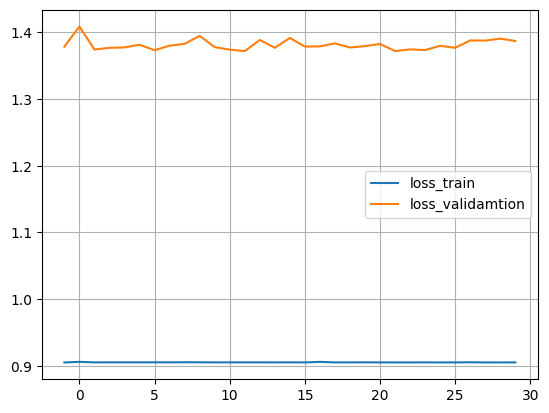

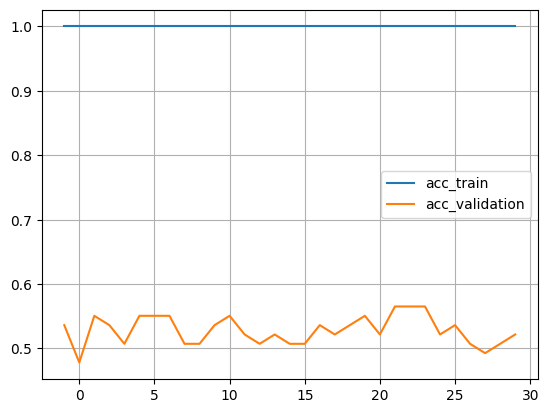

In [106]:
pylab.plot(trace[:,0],trace[:,1], label = "loss_train")
pylab.plot(trace[:,0],trace[:,2], label = "loss_validamtion")
pylab.legend()
pylab.grid()
pylab.show()
pylab.plot(trace[:,0],trace[:,3], label = "acc_train")
pylab.plot(trace[:,0],trace[:,4], label = "acc_validation")
pylab.legend()
pylab.grid()
pylab.show()

In [107]:
test_preds, test_true_tags = collect_preds(pipeline, valloader, criterion)

100%|██████████| 69/69 [00:01<00:00, 66.74it/s]

test | loss function val: 1.3735421178997427 accuracy: 0.5652173913043478


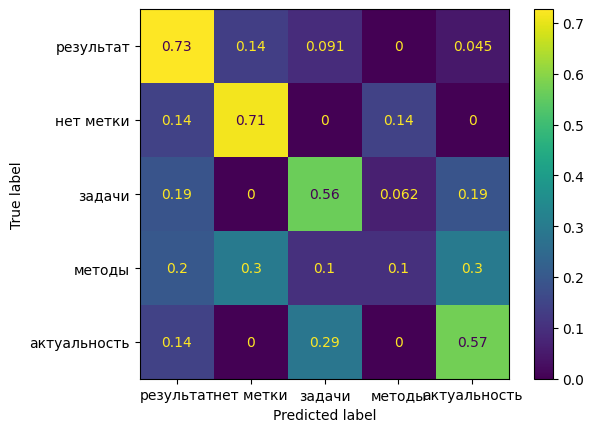

In [108]:
cm = skl.metrics.confusion_matrix(test_true_tags, test_preds, labels=list(LabtoNum.values()), normalize = 'true')
disp = skl.metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(LabtoNum.keys()))
disp.plot()
pylab.show()

In [109]:
train_preds, train_true_tags = collect_preds(pipeline, trainloader, criterion)

100%|██████████| 273/273 [00:04<00:00, 62.38it/s]

test | loss function val: 0.9048541677303803 accuracy: 1.0


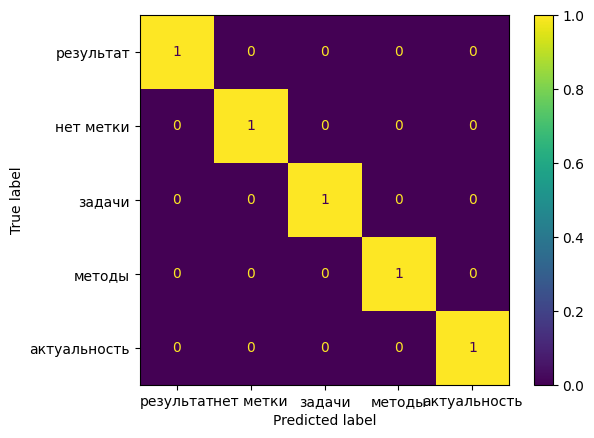

In [110]:
cm = skl.metrics.confusion_matrix(train_true_tags, train_preds, labels=list(LabtoNum.values()), normalize = 'true')
disp = skl.metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(LabtoNum.keys()))
disp.plot()
pylab.show()

In [111]:
f1 = skl.metrics.f1_score(test_true_tags, test_preds, average = 'weighted')
print(f1)

0.5428382055720561


In [62]:
test_preds, test_true_tags = collect_preds(pipeline, valloader, criterion, scores = True)

100%|██████████| 97/97 [00:01<00:00, 78.99it/s]

test | loss function val: 1.4300756651101654 accuracy: 0.0


In [63]:
t3 = skl.metrics.top_k_accuracy_score(test_true_tags, test_preds, k = 2)
print(t3)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (97,) + inhomogeneous part.

In [ ]:
# torch.save(pipeline.model.state_dict(), "full_model_segmentation_d2_0.5___.wt")

In [ ]:
model_rc = cp(pipeline.model)

In [ ]:
from transformers import RobertaForSequenceClassification, RobertaTokenizer, pipeline
class text_segment_classifier():
    def __init__(self, model_state_dict_file : str):
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        print("loading base model...")
        tokenizer = RobertaTokenizer.from_pretrained("mlsa-iai-msu-lab/sci-rus-tiny3")
        model = RobertaForSequenceClassification.from_pretrained("mlsa-iai-msu-lab/sci-rus-tiny3")
        print("reconfiguring classifier head...")
        # настройка модели и загрузка параметров.
        model.config.id2label = NumToLab
        model.config.label2id = LabtoNum
        model.classifier = torch.nn.Sequential(
            torch.nn.Linear(312,149),
            torch.nn.Tanh(),
            torch.nn.Dropout(p=0.1, inplace=False),
            torch.nn.Linear(149,5),
            torch.nn.Softmax(dim = -1)
        )
        print("loading new weights...")
        model.load_state_dict(torch.load(model_state_dict_file, weights_only=True))
        model = model.eval()
        # настройка пайплайна
        _pipeline = pipeline("text-classification", model=model,tokenizer=tokenizer, device = self.device)
        self.pipeline = _pipeline
        print("done!")

    def predict(self, sentence : str):
        with torch.no_grad():
            inp = self.pipeline.tokenizer(sentence, return_tensors = "pt")
            inp = inp.to(device)
            outputs = self.pipeline.model(**inp)
        res = outputs.logits[0][0]
        pred = int(torch.argmax(res))
        pred_calss = model.config.id2label[pred]
        return pred_calss

    def mass_predict(self, sentences : list, verbal : bool = False):
        preds = []
        it = tqdm(sentences) if verbal else sentences
        for sentence in it:
            with torch.no_grad():
                inp = self.pipeline.tokenizer(sentence, return_tensors = "pt")
                inp = inp.to(device)
                outputs = self.pipeline.model(**inp)
            res = outputs.logits[0][0]
            pred = int(torch.argmax(res))
            pred_calss = model.config.id2label[pred]
            preds.append(pred_calss)
        return preds

In [ ]:
texts = ['EMD — это "золотой стандарт" для точного сравнения распределений в NLP, особенно в WMD.',
        'Однако его применение требует компромисса между точностью и скоростью. Для большинства задач хватает косинусной меры, \
        но если нужно сравнить смысл слов (а не просто тексты), EMD — идеален.']

In [ ]:
classifier = text_segment_classifier("full_model_segmentation_0.74_.wt")

loading base model...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mlsa-iai-msu-lab/sci-rus-tiny3 and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


reconfiguring classifier head...
loading new weights...
done!


In [ ]:
classifier.mass_predict(texts, verbal = False)

['None', 'None']

In [ ]:
import optuna
def objective(trial):
    torch.cuda.empty_cache()
    # Диапазоны для поиска
    weight_decay = trial.suggest_float("weight_decay", 1e-10, 1e-2)
    bert_do = trial.suggest_categorical("bert_do", [True, False])
    head_do = trial.suggest_categorical("head_do", [True, False])
    head_im_dim = trial.suggest_int("head_dims", 50,250)
    head_im_activation = trial.suggest_categorical("head_im_activation", [0,1,2,3])
    af = [torch.nn.Tanh(), torch.nn.ReLU(), torch.nn.Sigmoid(), torch.nn.LeakyReLU(0.2)]
    head_activation = af[head_im_activation]

    ##=====================model
    from transformers import RobertaForSequenceClassification, RobertaTokenizer, pipeline
    tokenizer = RobertaTokenizer.from_pretrained("mlsa-iai-msu-lab/sci-rus-tiny3")
    model = RobertaForSequenceClassification.from_pretrained("mlsa-iai-msu-lab/sci-rus-tiny3")
    for param in model.roberta.parameters(): # выключаем обучение в берте
        param.requires_grad = False 
    model.config.id2label = NumToLab
    model.config.label2id = LabtoNum
    if head_do:
        model.classifier = torch.nn.Sequential(
            torch.nn.Linear(312,head_im_dim),
            head_activation,
            torch.nn.Dropout(p=0.1, inplace=False),
            torch.nn.Linear(head_im_dim,5),
            torch.nn.Softmax(dim = -1)
        )
    else:
        model.classifier = torch.nn.Sequential(
            torch.nn.Linear(312,head_im_dim),
            head_activation,
            torch.nn.Linear(head_im_dim,5),
            torch.nn.Softmax(dim = -1)
        )
    if torch.cuda.is_available():
        model.to(device)
    ##=====================model
    pipeline = pipeline("text-classification", model=model,tokenizer=tokenizer, device = device)
    
    criterion = torch.nn.CrossEntropyLoss(weight = torch.tensor(tags_weights, dtype = torch.float32).to(device))
    optimizer = torch.optim.Adam(pipeline.model.classifier.parameters(), weight_decay = weight_decay)
    # Запуск обучения с текущими параметрами
    _, _, best_acc = train_model(pipeline, 
                                 trainloader, 
                                 valloader, 
                                 criterion, 
                                 optimizer, 
                                 num_epochs = 350, 
                                 verbal = False, 
                                 bert_dropout = bert_do )
    
    return best_acc  

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=80)

In [ ]:
study.best_params

{'weight_decay': 0.006903673153394426,
 'bert_do': False,
 'head_dims': 149,
 'head_im_activation': 0}

### Проверка на разных статьях.

In [ ]:
p_texts = []
g_cnt = 0
e_cnt = 0
w_cnt = 0
for p_id in tqdm(range(3100,3200)):
    responce = requests.get(f"http://193.232.208.58:9001/filewatcher/download_filearchive?id_publ={p_id}&whash=1")
    try:
        for elm in json.loads(responce.text)['publications']:
            if elm['publication']['p_text'].count('а') > elm['publication']['p_text'].count('a'):
                p_texts.append(elm['publication']['p_text'])
                g_cnt += 1
            else:
                w_cnt += 1
    except KeyError:
        e_cnt += 1
print("OK: ", g_cnt)
print("K-ERROR: ",e_cnt)
print("LANG-ERROR: ",w_cnt)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 35.69it/s]

OK:  47
K-ERROR:  8
LANG-ERROR:  45


In [ ]:
split_texts = []
for cur_text in p_texts:
    split_text = []
    join_next = False
    for sent in cur_text.split('. '):
        # print(sent)
        if len(sent) > 2000:
            continue
        # просто по точкам делить не стоит.
        if join_next:
            # print("joining")
            split_text[-1] = split_text[-1] + " " + sent
            join_next = False
            continue
        # принимаем решение, добавлять ли предложение или нет.
        if len(sent) < 30:
            # print("passing")
            continue        
        # про несправедливые разбиения
        if (not re.search("рис$",sent.lower()) is None) or (not re.search("табл$",sent.lower()) is None):
            # print("will join")
            join_next = True
            split_text.append(sent)
            continue
        
        # print("adding")
        split_text.append(sent)
    # for i in (split_text):
    #     print(i)
    split_texts.append(split_text)

In [ ]:
classifier = text_segment_classifier("full_model_segmentation_0.74_.wt")

loading base model...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mlsa-iai-msu-lab/sci-rus-tiny3 and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight', 'classifier.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


reconfiguring classifier head...
loading new weights...
done!


In [ ]:
all_text_segmented = []
for text in tqdm(split_texts):
    text_dict = {}
    preds = classifier.mass_predict(text, verbal = False)
    for i in range(len(preds)):
        text_dict.setdefault(preds[i],[])
        text_dict[preds[i]].append(text[i])
    all_text_segmented.append(text_dict)

100%|██████████████████████████████████████████████████████████████████████████████████| 47/47 [00:21<00:00,  2.14it/s]


In [ ]:
i = 18
for tag in ['Goal','Obl','Resl','Algo','None']:
    print("====================================================================================================================================")
    print("====================================================================================================================================")
    print(f"|| \\{tag}/ ||")
    if tag not in all_text_segmented[i]:
        print("NONE")
        continue
    for sent in all_text_segmented[i][tag]:
        print("----------------")
        print(sent)

|| \Goal/ ||
----------------
Проведенное изучение проблем управления долгосрочным развитием СЭС-регионов позволило выявить среди федеральных земель Германии наличие своеобразной трехуровневой структуры, а именно: города-земли Гамбург и Бремен, находящиеся на высшем уровне; второй уровень -это «старые" федеральные земли с достаточно высоким уровнем доходов и благосостояния
|| \Obl/ ||
----------------
Управление регионом -крупномасштабной социально-экономической системой (СЭС)представляет собой сложнейший процесс реализации управленческо-организационных мероприятий (УОМ), направленных на более рациональное использование потенциальных возможностей системы
----------------
Средства, остающиеся в распоряжении регионального руководства в качестве основной "движущей силы" развития региона (задаваемые разностью ∆ рег /чел = ВВП рег /чел -РД рег /чел), определяются "жесткостью", проявляемой в процессе управления
----------------
При разработке адекватной модели эволюции сложной СЭС-региона бу

In [ ]:
## По сопоставлению...
# 1. по предложениям
# 2. по текстам
# a. sci-rus эмбединги
# b. по графам ?